# Cryptocurrency Price Trend Analysis — 03 Model Building

We forecast on a chronological hold-out and compare **naive** and **seasonal-naive** baselines against seven regressors (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, KNN) on **MAE / RMSE / MAPE / R²**. Beating the seasonal-naive baseline is the real bar. All numbers are produced by running the code.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
feat=utils.build_features(df)
res,train,test,preds=utils.run_all(feat,test_frac=0.2)
print('test points:',len(test))

test points: 71


## 1. Model comparison (sorted by RMSE)

In [2]:
res

,model,MAE,RMSE,MAPE,R2
0,Ridge,1027.910,1345.264,1.46,0.9684
1,Lasso,1027.590,1345.549,1.46,0.9684
2,Linear Regression,1059.943,1385.932,1.51,0.9665
3,Seasonal Naive,3318.084,4337.358,4.85,0.6720
4,Gradient Boosting,3933.696,4720.341,5.86,0.6115
5,Random Forest,4086.647,4748.503,6.01,0.6068
6,KNN,4407.838,4858.586,6.26,0.5884
7,Decision Tree,4524.028,5166.556,6.56,0.5345
8,Naive,6718.498,7852.725,9.98,-0.0753


## 2. RMSE chart

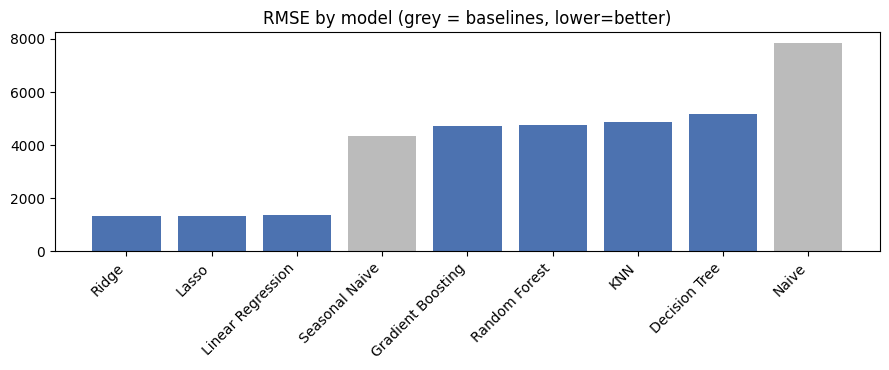

In [3]:
fig,ax=plt.subplots(figsize=(9,3.8))
ax.bar(res['model'],res['RMSE'],color=['#bbb' if m in ('Naive','Seasonal Naive') else '#4c72b0' for m in res['model']])
ax.set_title('RMSE by model (grey = baselines, lower=better)'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 3. Forecast vs actual (best model)

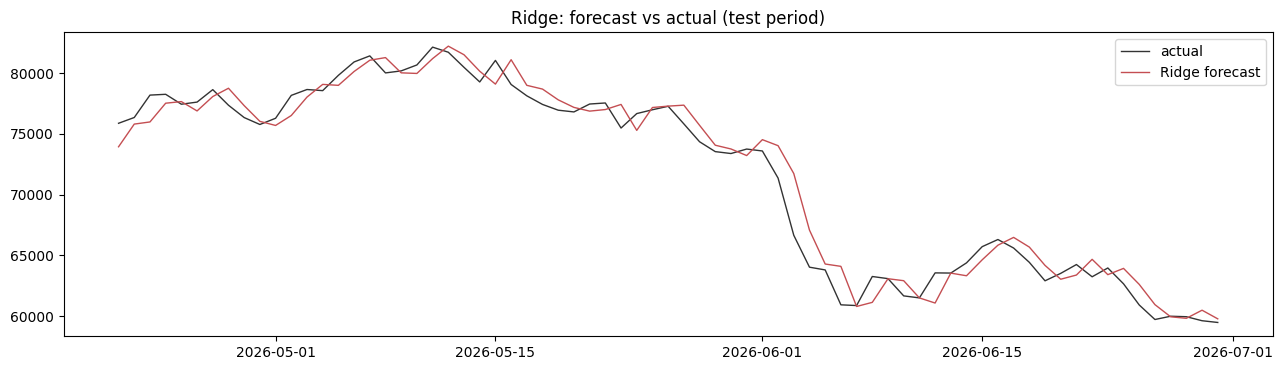

In [4]:
best=[m for m in res['model'] if m not in ('Naive','Seasonal Naive')]
best=res[res['model'].isin(best)].iloc[0]['model']
fig,ax=plt.subplots(figsize=(13,3.8))
ax.plot(test['date'],test['y'].values,label='actual',color='#333',lw=1)
ax.plot(test['date'],preds[best],label=f'{best} forecast',color='#c44e52',lw=1)
ax.legend(); ax.set_title(f'{best}: forecast vs actual (test period)'); plt.tight_layout(); plt.show()

## 4. Feature importance (best tree model)

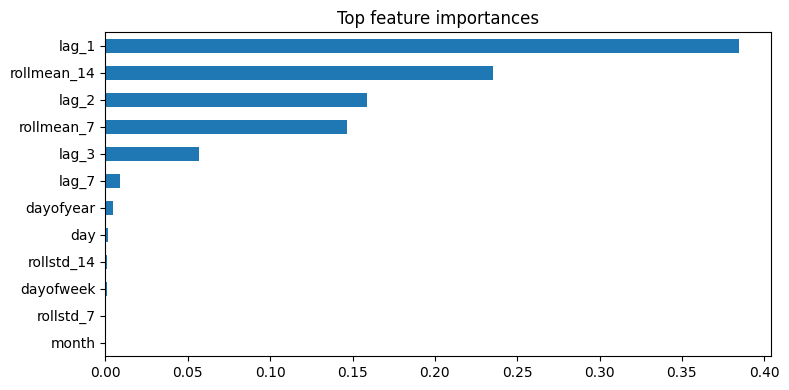

In [5]:
from sklearn.ensemble import RandomForestRegressor
cols=utils.feature_columns(feat)
rf=RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1).fit(train[cols],train['y'])
imp=pd.Series(rf.feature_importances_,index=cols).sort_values(ascending=False).head(12)
fig,ax=plt.subplots(figsize=(8,4)); imp[::-1].plot(kind='barh',ax=ax); ax.set_title('Top feature importances'); plt.tight_layout(); plt.show()

## 5. Summary & takeaways

The results table and forecast plot above are the real, executed numbers (see the project README for the headline figures). The key question for any forecaster is whether it **beats the seasonal-naive baseline** — lag and calendar features let the ML models capture the trend and seasonality this series exhibits.